# CodeBERTScore Plots (from precomputed stats)
Load ablation-results_statistics.csv and render box-style summaries without recalculating metrics.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [12, 6]

MODEL_LABELS = {
    "gpt5": "GPT-5",
    "phi4": "Phi4",
    "qw32": "Qw32B",
}
# Custom brand colors with fallbacks for unspecified models
OVERRIDE_COLORS = {
    "qw32": "#9289E8",
    "gpt5": "#70A597",
    "phi4": "#689DDD",
}
PROCESSOR_LABELS = {"dp": "DP", "mc": "MC", "sg": "ArdSG", "psg": "PySG-CPU", "tpusg": "PySG-TPU"}
PROMPT_LABELS = {
    "original": "Prompt Original",
    "abla-l1": "Prompt L1",
    "abla-l2": "Prompt L2",
    "abla-1p": "Prompt L1-P",
    "abla-2p": "Prompt L2-P",
}


palette = sns.color_palette("tab20", n_colors=len(MODEL_LABELS))
MODEL_COLORS = {}
for i, m in enumerate(MODEL_LABELS.keys()):
    MODEL_COLORS[m] = OVERRIDE_COLORS.get(m, palette[i % len(palette)])

NOTEBOOK_DIR = Path.cwd()
STATS_PATH_CANDIDATES = [
    NOTEBOOK_DIR / "ablation-results_statistics.csv",
    NOTEBOOK_DIR.parent / "plottings" / "ablation-results_statistics.csv",
    NOTEBOOK_DIR / "analyser-results" / "ablation-results_statistics.csv",
]

STATS_FILE = next((p for p in STATS_PATH_CANDIDATES if p.exists()), None)
if STATS_FILE is None:
    raise FileNotFoundError("ablation-results_statistics.csv not found in expected locations.")

stats = pd.read_csv(STATS_FILE)
print(f"Loaded {len(stats)} rows from {STATS_FILE}")
print(f"Metrics: {sorted(stats['metric'].unique())}")
print(f"Prompt levels: {sorted(stats['Prompt_level'].unique())}")
print(f"Processors: {sorted(stats['Processor'].unique())}")

metrics = sorted(stats["metric"].unique())
processors = sorted(stats["Processor"].unique())
prompt_levels_seen = list(stats["Prompt_level"].unique())
prompts = [p for p in PROMPT_LABELS if p in prompt_levels_seen]
extra_prompts = [p for p in prompt_levels_seen if p not in PROMPT_LABELS]
prompts += sorted(extra_prompts)

stats.head()

Loaded 104 rows from /Users/hann/Projects/benchmark-tinyml_llm-2026/codebertscore-similarity/analyser-results/ablation-results_statistics.csv
Metrics: ['F1', 'F3', 'Precision', 'Recall']
Prompt levels: ['abla-1p', 'abla-2p', 'abla-l1', 'abla-l2', 'original']
Processors: ['psg', 'sg', 'tpusg']


,metric,Model,Prompt_level,Processor,count,mean,median,std,min,Q1,Q3,max,IQR,lower_whisker,upper_whisker,outlier_count
0,Precision,gpt5,abla-l1,psg,30,0.826513,0.827300,0.010443,0.807427,0.818332,0.834930,0.847317,0.016598,0.807427,0.847317,0
1,Precision,gpt5,abla-l1,sg,3,0.831381,0.836078,0.013932,0.815708,0.825893,0.839218,0.842357,0.013324,0.815708,0.842357,0
2,Precision,gpt5,abla-l1,tpusg,30,0.810734,0.816312,0.014359,0.783676,0.797119,0.819960,0.834903,0.022841,0.783676,0.834903,0
3,Precision,gpt5,abla-l2,psg,30,0.798674,0.799578,0.013972,0.776612,0.788429,0.806920,0.821753,0.018491,0.776612,0.821753,0
4,Precision,gpt5,abla-l2,sg,21,0.819970,0.816256,0.009968,0.807338,0.813042,0.824660,0.839926,0.011618,0.807338,0.839926,0


Helper to convert precomputed statistics into matplotlib.bxp input.

In [6]:
BOX_KWARGS = {
    "medianprops": {"color": "black", "linewidth": 2},
    "meanprops": {"marker": "x", "markeredgecolor": "black", "markersize": 7, "linestyle": "none"},
    "whiskerprops": {"color": "black", "linewidth": 1.5},
    "capprops": {"color": "black", "linewidth": 1.5},
    "boxprops": {"edgecolor": "black", "linewidth": 1.5},
}

def make_bxp_rows(subset: pd.DataFrame):
    subset = subset.sort_values("Model")
    bxp_rows = []
    colors = []
    model_order = []
    for _, row in subset.iterrows():
        bxp_rows.append({
            "label": MODEL_LABELS.get(row["Model"], row["Model"]),
            "med": row["median"],
            "q1": row["Q1"],
            "q3": row["Q3"],
            "whislo": row["lower_whisker"],
            "whishi": row["upper_whisker"],
            "mean": row["mean"],
            "fliers": [],
        })
        colors.append(MODEL_COLORS.get(row["Model"], "lightgray"))
        model_order.append(row["Model"])

    return bxp_rows, colors, model_order

def apply_box_colors(artists, colors):
    for patch, color in zip(artists["boxes"], colors):
        patch.set_facecolor(color)

def set_axis_limits(ax, subset, pad_frac=0.05):
    y_min = subset["lower_whisker"].min()
    y_max = subset["upper_whisker"].max()
    y_range = y_max - y_min if y_max > y_min else 0.05
    ax.set_ylim(max(0, y_min - pad_frac * y_range), min(1, y_max + pad_frac * y_range))

### Prompt-level comparison per processor
For each processor, compare prompt levels side-by-side (boxes per model) with per-plot y-limits.

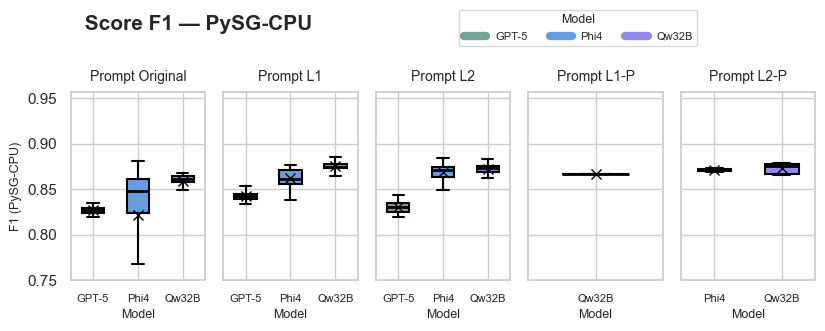

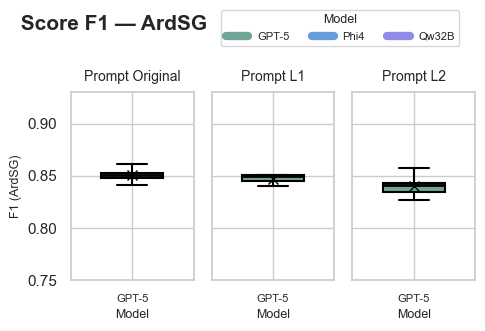

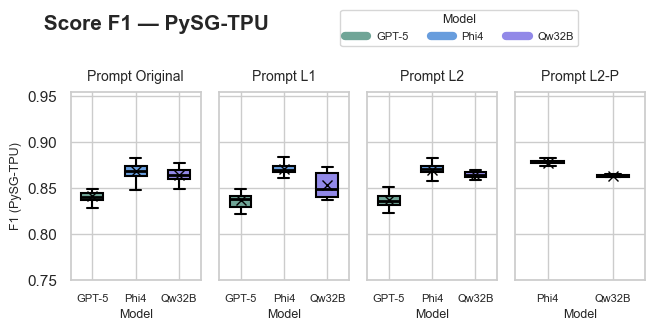

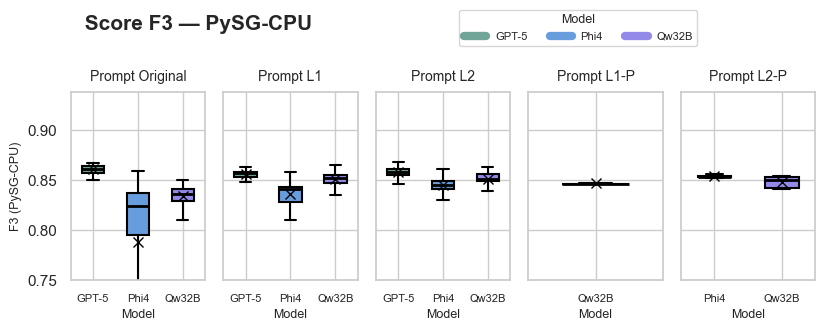

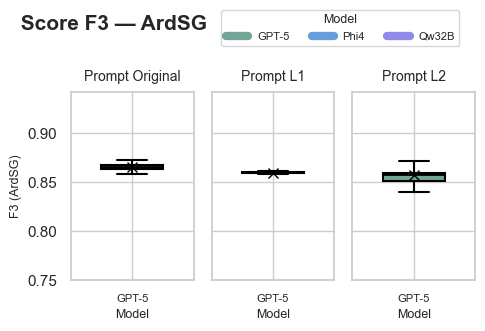

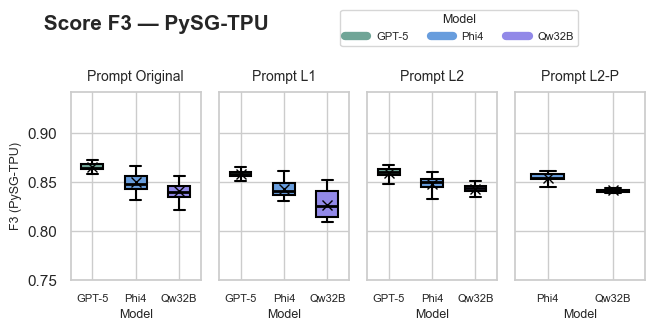

In [7]:
def plot_by_processor(metric, proc, y_limits=None):
    # Create an ordered list of prompt levels that actually have data for this metric/processor pair.
    prompt_slots = []
    # Iterate over all prompt levels discovered earlier in the notebook.
    for p in prompts:
        # Filter rows for the current metric, processor, and prompt level.
        subset = stats[(stats["metric"] == metric) & (stats["Processor"] == proc) & (stats["Prompt_level"] == p)]
        # Keep this prompt only if the filtered subset is not empty.
        if not subset.empty:
            # Append valid prompt level to the plotting order.
            prompt_slots.append(p)

    # Stop early when there is nothing to visualize for this combination.
    if not prompt_slots:
        # Print a readable skip message for traceability in notebook output.
        print(f"No data for {metric} / {proc}; skipping plot.")
        # Exit the function without creating a figure.
        return

    # Create one row of subplots where each column is one prompt level.
    fig, axes = plt.subplots(
        # Use a single row layout for side-by-side comparison.
        nrows=1,
        # Number of columns equals number of available prompt levels.
        ncols=len(prompt_slots),
        # Scale width with number of panels while keeping a compact height.
        figsize=(len(prompt_slots) * 1.7, 3.6),
        # Share y-axis so distributions are directly comparable across panels.
        sharey=True,
    )

    # Normalize axes to a 1D array so indexing works for both single and multiple panels.
    axes = np.array(axes).reshape(1, len(prompt_slots))[0]

    # Build legend handles using model colors so the legend matches box fill colors.
    legend_handles = [Line2D([0], [0], color=MODEL_COLORS[m], lw=6) for m in MODEL_LABELS]
    # Build legend labels from user-friendly model names.
    legend_labels = [MODEL_LABELS[m] for m in MODEL_LABELS]

    # Prepare y-limits: if user did not pass y_limits, compute automatic shared limits.
    all_subsets = stats[(stats["metric"] == metric) & (stats["Processor"] == proc)]
    # Compute automatic limits only when no explicit limits were provided and data exists.
    if y_limits is None and not all_subsets.empty:
        # Read the global maximum whisker over all prompts for this metric/processor.
        y_max_global = all_subsets["upper_whisker"].max()
        # Build a safe range term to avoid zero-range edge cases.
        y_range_global = y_max_global if y_max_global > 0 else 0.05
        # Anchor lower bound at zero for score-style plots.
        y_lo = 0
        # Add a small headroom above the max and clamp to 1.
        y_hi = min(1, y_max_global + 0.08 * y_range_global)
        # Store computed limits as a tuple for reuse in every subplot.
        # y_limits = (y_lo, y_hi)
        y_limits = (0.75, y_hi)

    # Iterate through each prompt panel and draw its box summaries.
    for j, prompt in enumerate(prompt_slots):
        # Select current subplot axis by index.
        ax = axes[j]
        # Filter data for the current metric, processor, and prompt.
        subset = stats[(stats["metric"] == metric) & (stats["Processor"] == proc) & (stats["Prompt_level"] == prompt)]
        # Convert summary statistics rows into matplotlib bxp input format.
        bxp_rows, colors, model_order = make_bxp_rows(subset)
        # Draw box plots from precomputed quartiles/whiskers instead of raw samples.
        artists = ax.bxp(
            # Structured rows with medians, quartiles, whiskers, and means.
            bxp_rows,
            # Do not draw fliers because these are summary-driven boxes.
            showfliers=False,
            # Draw mean marker from provided summary values.
            showmeans=True,
            # Enable patch artists so face colors can be customized.
            patch_artist=True,
            # Keep boxes moderately narrow for readability.
            widths=0.5,
            # Reuse global styling dictionary for visual consistency.
            **BOX_KWARGS,
        )

        # Apply per-model fill colors to the boxes.
        apply_box_colors(artists, colors)
        # Build x-tick labels in the exact plotted model order.
        labels = [MODEL_LABELS.get(m, m) for m in model_order]
        # Set x-tick labels with compact font size.
        ax.set_xticklabels(labels, fontsize=8)
        # Set panel title to human-friendly prompt label.
        ax.set_title(PROMPT_LABELS.get(prompt, prompt), fontsize=10, pad=8)
        # Label x-axis as model name category.
        ax.set_xlabel("Model", fontsize=9)

        # Add y-axis label only to the first subplot to reduce clutter.
        if j == 0:
            # Include metric name and processor label in the y-axis title.
            ax.set_ylabel(f"{metric} ({PROCESSOR_LABELS.get(proc, proc)})", fontsize=9)
        else:
            # Remove duplicate y-label text on non-first panels.
            ax.set_ylabel("")
            # Hide left tick labels on non-first panels in shared-y layout.
            ax.tick_params(labelleft=False)

        # Apply explicit or auto-computed y-limits when available.
        if y_limits is not None:
            # Unpack (low, high) tuple into matplotlib axis limit setter.
            ax.set_ylim(*y_limits)

    # Add figure-level title for metric and processor context.
    fig.suptitle(
        # Include score metric and friendly processor name.
        f" Score {metric} — {PROCESSOR_LABELS.get(proc, proc)}",
        # Use a slightly larger title font.
        fontsize=15,
        # Emphasize title weight for hierarchy.
        fontweight="bold",
        # Place title near top while preserving room for legend.
        y=0.9,
        # Shift title horizontally to better align with subplot block.
        x=0.25,
    )

    # Add one shared legend above panels for model color mapping.
    fig.legend(
        # Reuse custom color handles.
        legend_handles,
        # Reuse friendly model names.
        legend_labels,
        # Add legend title.
        title="Model",
        # Put all model entries in one row.
        ncol=len(legend_labels),
        # Position at upper center area of figure.
        loc="upper center",
        # Keep legend text compact.
        fontsize=8,
        # Keep legend title slightly larger than items.
        title_fontsize=9,
        # Fine-tune anchor for balance with suptitle.
        bbox_to_anchor=(0.7, 0.93),
    )

    # Reserve top margin for title + legend and tighten remaining spacing.
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    # Render the figure in the notebook output.
    plt.show()

# Generate plots for both score metrics across all processors using auto y-limits.
for metric in ['F1', 'F3']:
    # Iterate every processor present in the dataset.
    for proc in processors:
        # Call function with default y_limits=None (auto behavior).
        plot_by_processor(metric, proc)

# Example for fixed manual limits:
# plot_by_processor('F1', 'sg', y_limits=(0.2, 0.9))

### Global min/max values across all statistics
Find the absolute lowest and highest numeric values present in ablation-results_statistics.csv, with context rows.

In [8]:
import numpy as np

numeric_cols = stats.select_dtypes(include=[np.number]).columns
min_idx = stats[numeric_cols].stack().idxmin()
max_idx = stats[numeric_cols].stack().idxmax()

min_row_label, min_col = min_idx
max_row_label, max_col = max_idx

min_row = stats.loc[min_row_label]
max_row = stats.loc[max_row_label]

print("=== Global minimum across all numeric fields ===")
print(f"Value: {stats.at[min_row_label, min_col]:.6f} (column: {min_col})")
print(min_row[['metric', 'Model', 'Prompt_level', 'Processor']])
print()
print("=== Global maximum across all numeric fields ===")
print(f"Value: {stats.at[max_row_label, max_col]:.6f} (column: {max_col})")
print(max_row[['metric', 'Model', 'Prompt_level', 'Processor']])

=== Global minimum across all numeric fields ===
Value: 0.000000 (column: outlier_count)
metric          Precision
Model                gpt5
Prompt_level      abla-l1
Processor             psg
Name: 0, dtype: object

=== Global maximum across all numeric fields ===
Value: 48.000000 (column: count)
metric          Precision
Model                phi4
Prompt_level      abla-2p
Processor           tpusg
Name: 10, dtype: object
